# Detección de comunidades con el algoritmo de Louvain




In [1]:
import pandas as pd
import numpy as np
import re
from collections import Counter, defaultdict
import networkx as nx
import community as community_louvain  
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv('tweets.csv')
print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
print(f"Autores únicos: {df['author'].nunique()}")
df.head(3)

Filas: 52,542  |  Columnas: 10
Autores únicos: 20


,author,content,country,date_time,id,language,latitude,longitude,number_of_likes,number_of_shares
0,katyperry,Is history repeating itself...?#DONTNORMALIZEH...,NaN,12/01/2017 19:52,8.196330e+17,en,NaN,NaN,7900,3472
1,katyperry,@barackobama Thank you for your incredible gra...,NaN,11/01/2017 08:38,8.191010e+17,en,NaN,NaN,3689,1380
2,katyperry,Life goals. https://t.co/XIn1qKMKQl,NaN,11/01/2017 02:52,8.190140e+17,en,NaN,NaN,10341,2387


In [2]:
df['author'].value_counts()

author
TheEllenShow     3147
jimmyfallon      3123
ArianaGrande     3104
YouTube          3077
KimKardashian    2939
katyperry        2924
selenagomez      2913
rihanna          2877
BarackObama      2863
britneyspears    2776
instagram        2577
shakira          2530
Cristiano        2507
jtimberlake      2478
ladygaga         2329
Twitter          2290
ddlovato         2217
taylorswift13    2029
justinbieber     2000
cnnbrk           1842
Name: count, dtype: int64

In [3]:
mention_re = re.compile(r'@(\w+)')
df['mentions'] = df['content'].apply(lambda x: [m.lower() for m in mention_re.findall(str(x))])

authors = sorted(df['author'].unique())

author_handle_counts = defaultdict(Counter)
for auth, mlist in zip(df['author'], df['mentions']):
    for h in mlist:
        if h == auth.lower():
            continue
        author_handle_counts[auth][h] += 1

handle_df = Counter()
for auth, c in author_handle_counts.items():
    for h in c:
        handle_df[h] += 1

print(f"Cuentas distintas mencionadas en total: {len(handle_df):,}")
print(f"Mencionadas por >= 3 autores distintos (nuestra muestra): "
      f"{sum(1 for v in handle_df.values() if v >= 3)}")

Cuentas distintas mencionadas en total: 10,605
Mencionadas por >= 3 autores distintos (nuestra muestra): 504


In [ ]:
MIN_AUTHORS = 3
kept_handles = sorted([h for h, d in handle_df.items() if d >= MIN_AUTHORS])
handle_index = {h: i for i, h in enumerate(kept_handles)}
N, M = len(authors), len(kept_handles)
print(f"Autores (U): {N}   |   Cuentas-puente en la muestra (V): {M}")

mat = np.zeros((N, M))
for ai, a in enumerate(authors):
    for h, cnt in author_handle_counts[a].items():
        if h in handle_index:
            mat[ai, handle_index[h]] = cnt

idf = np.log(N / np.array([handle_df[h] for h in kept_handles]))
tfidf = mat * idf
print("Matriz autor x cuenta-mencionada (TF-IDF):", tfidf.shape)

Autores (U): 20   |   Cuentas-puente en la muestra (V): 504
Matriz autor x cuenta-mencionada (TF-IDF): (20, 504)


In [17]:
kept_set = set(kept_handles)
filas_bip = []
for a in authors:
    for h, cnt in author_handle_counts[a].items():
        if h in kept_set:
            idf_h = idf[handle_index[h]]
            filas_bip.append((a, h, cnt, round(idf_h, 3), round(cnt * idf_h, 3)))

tabla_bipartita = pd.DataFrame(
    filas_bip, columns=['autor', 'cuenta_mencionada', 'conteo', 'idf', 'peso_tfidf']
).sort_values('peso_tfidf', ascending=False).reset_index(drop=True)

print(f"Total de aristas (relaciones autor-mención) en la muestra: {len(tabla_bipartita)}")
tabla_bipartita.head(15)

Total de aristas (relaciones autor-mención) en la muestra: 2305


,autor,cuenta_mencionada,conteo,idf,peso_tfidf
0,justinbieber,skrillex,75,1.897,142.284
1,shakira,nbcthevoice,138,0.916,126.448
2,ladygaga,itstonybennett,51,1.609,82.081
3,ArianaGrande,frankiejgrande,42,1.897,79.679
4,jimmyfallon,theroots,49,1.609,78.862
5,shakira,unicef,54,1.386,74.860
6,justinbieber,diplo,50,1.386,69.315
7,shakira,blakeshelton,43,1.609,69.206
8,britneyspears,iamwill,54,1.204,65.015
9,ddlovato,nickjonas,51,1.204,61.403


In [5]:
norms = np.linalg.norm(tfidf, axis=1, keepdims=True)
norms[norms == 0] = 1e-9
tfidf_norm = tfidf / norms
sim = tfidf_norm @ tfidf_norm.T
np.fill_diagonal(sim, 0)

print(f"Similitud coseno -> min={sim.min():.4f}  max={sim.max():.4f}  "
      f"media (no-cero)={sim[sim>0].mean():.4f}")

Similitud coseno -> min=0.0000  max=0.4298  media (no-cero)=0.0702


### 3.1 Filtrado de aristas débiles



In [6]:
vals = sim[np.triu_indices(N, 1)]
vals_nonzero = vals[vals > 0]

resultados = []
for q in [0, 25,40, 50, 60, 70, 75, 80]:
    thr = np.percentile(vals_nonzero, q)
    Gq = nx.Graph()
    Gq.add_nodes_from(authors)
    for i in range(N):
        for j in range(i+1, N):
            if sim[i, j] > thr:
                Gq.add_edge(authors[i], authors[j], weight=float(sim[i, j]))
    if Gq.number_of_edges() == 0:
        continue
    part_q = community_louvain.best_partition(Gq, weight='weight', random_state=42)
    mod_q = community_louvain.modularity(part_q, Gq, weight='weight')
    resultados.append((q, thr, Gq.number_of_edges(), len(set(part_q.values())), mod_q))

res_df = pd.DataFrame(resultados, columns=['percentil', 'umbral', 'aristas', 'n_comunidades', 'modularidad'])
res_df

,percentil,umbral,aristas,n_comunidades,modularidad
0,0,0.000086,184,3,0.115319
1,25,0.026646,138,3,0.128481
2,40,0.043052,111,3,0.151725
3,50,0.051344,92,3,0.162866
4,60,0.065863,74,3,0.180787
5,70,0.090659,56,3,0.248148
6,75,0.098568,46,3,0.249991
7,80,0.110940,37,7,0.250052


In [7]:
thr_final = np.percentile(vals_nonzero, 50)

G = nx.Graph()
G.add_nodes_from(authors)
for i in range(N):
    for j in range(i+1, N):
        if sim[i, j] > thr_final:
            G.add_edge(authors[i], authors[j], weight=float(sim[i, j]))

print(f"Grafo proyectado final: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas "
      f"(umbral de similitud = {thr_final:.4f})")

Grafo proyectado final: 20 nodos, 92 aristas (umbral de similitud = 0.0513)


In [8]:
partition = community_louvain.best_partition(G, weight='weight', random_state=42)
modularidad = community_louvain.modularity(partition, G, weight='weight')

grupos = defaultdict(list)
for nodo, com in partition.items():
    grupos[com].append(nodo)

print(f"Modularidad Q = {modularidad:.4f}")
print(f"Número de comunidades encontradas: {len(grupos)}\n")
for com, miembros in sorted(grupos.items()):
    print(f"Comunidad {com} ({len(miembros)} cuentas): {sorted(miembros)}")

Modularidad Q = 0.1629
Número de comunidades encontradas: 3

Comunidad 0 (11 cuentas): ['ArianaGrande', 'KimKardashian', 'britneyspears', 'ddlovato', 'justinbieber', 'katyperry', 'ladygaga', 'rihanna', 'selenagomez', 'shakira', 'taylorswift13']
Comunidad 1 (4 cuentas): ['Cristiano', 'TheEllenShow', 'jimmyfallon', 'jtimberlake']
Comunidad 2 (5 cuentas): ['BarackObama', 'Twitter', 'YouTube', 'cnnbrk', 'instagram']


## 5. Visualización del grafo proyectado y sus comunidades


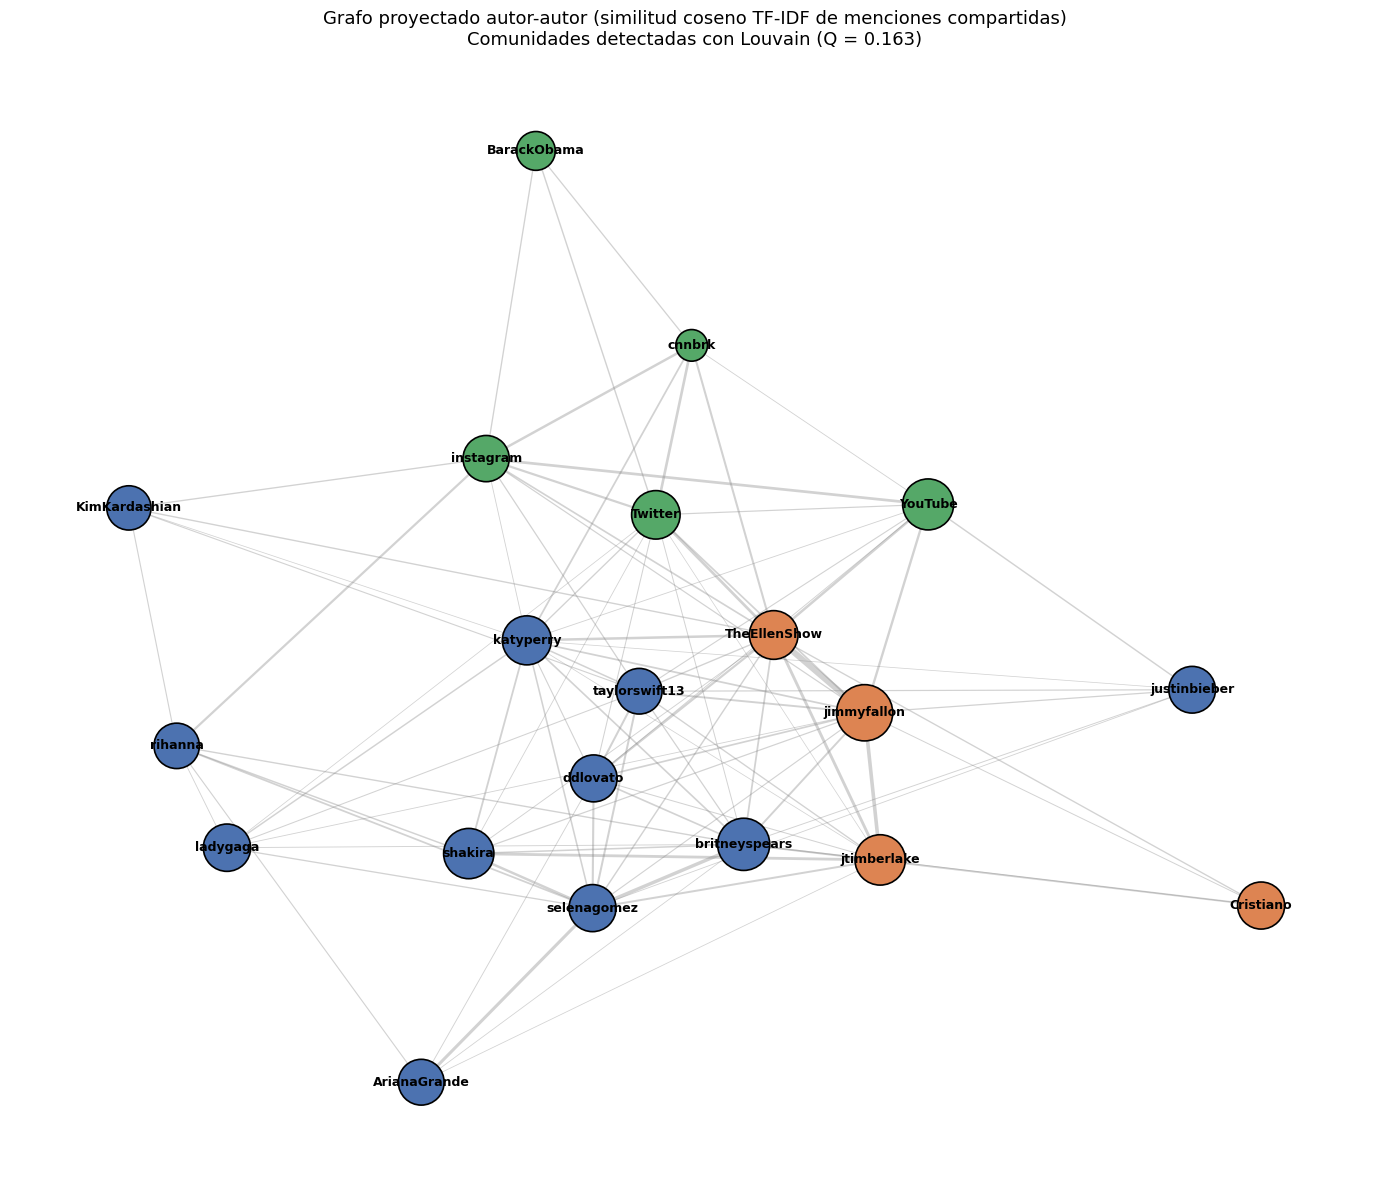

In [9]:
pos = nx.spring_layout(G, weight='weight', seed=11, k=2.6, iterations=500)

palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
node_colors = [palette[partition[n] % len(palette)] for n in G.nodes()]
node_sizes = [400 + 22 * np.sqrt(sum(author_handle_counts[n].values())) for n in G.nodes()]

fig, ax = plt.subplots(figsize=(14, 12))
edge_weights = [G[u][v]['weight'] * 10 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=edge_weights, edge_color='gray', alpha=0.35, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                        edgecolors='black', linewidths=1.2, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', ax=ax)
ax.set_title("Grafo proyectado autor-autor (similitud coseno TF-IDF de menciones compartidas)\n"
             f"Comunidades detectadas con Louvain (Q = {modularidad:.3f})", fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('louvain_communities.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Análisis de cada comunidad




In [10]:
ai_index = {a: i for i, a in enumerate(authors)}
kept_set = set(kept_handles)

for com, miembros in sorted(grupos.items()):
    print(f"\n{'='*70}\nCOMUNIDAD {com}  —  {len(miembros)} cuentas: {sorted(miembros)}")
    agg = Counter()
    for a in miembros:
        agg.update({h: c for h, c in author_handle_counts[a].items() if h in kept_set})
    print("Top cuentas-puente compartidas:", agg.most_common(10))

    pares = [(a, b) for idx, a in enumerate(miembros) for b in miembros[idx+1:]]
    if pares:
        sims = [sim[ai_index[a], ai_index[b]] for a, b in pares]
        print(f"Similitud coseno promedio interna: {np.mean(sims):.4f}")


COMUNIDAD 0  —  11 cuentas: ['ArianaGrande', 'KimKardashian', 'britneyspears', 'ddlovato', 'justinbieber', 'katyperry', 'ladygaga', 'rihanna', 'selenagomez', 'shakira', 'taylorswift13']
Top cuentas-puente compartidas: [('nbcthevoice', 143), ('vevo', 133), ('itunesmusic', 119), ('spotify', 90), ('billboard', 78), ('skrillex', 76), ('applemusic', 75), ('theellenshow', 69), ('unicef', 69), ('rihanna', 64)]
Similitud coseno promedio interna: 0.0765

COMUNIDAD 1  —  4 cuentas: ['Cristiano', 'TheEllenShow', 'jimmyfallon', 'jtimberlake']
Top cuentas-puente compartidas: [('theroots', 52), ('jtimberlake', 46), ('justinbieber', 43), ('jimmyfallon', 32), ('blakeshelton', 29), ('hillaryclinton', 28), ('questlove', 27), ('target', 26), ('potus', 25), ('arianagrande', 25)]
Similitud coseno promedio interna: 0.1867

COMUNIDAD 2  —  5 cuentas: ['BarackObama', 'Twitter', 'YouTube', 'cnnbrk', 'instagram']
Top cuentas-puente compartidas: [('iisuperwomanii', 36), ('vp', 28), ('johnlegend', 19), ('flotus'

### 6.1 Comunidad 0 — Artistas musicales (pop / música)

**Miembros:** ArianaGrande, KimKardashian, britneyspears, ddlovato, justinbieber, katyperry, ladygaga, rihanna, selenagomez, shakira, taylorswift13.

### 6.2 Comunidad 1 — Late-night / entretenimiento televisivo

**Miembros:** Cristiano, TheEllenShow, jimmyfallon, jtimberlake.

### 6.3 Comunidad 2 — Cuentas institucionales / medios / plataformas

**Miembros:** BarackObama, Twitter, YouTube, cnnbrk, instagram.


In [11]:
df['date_time_parsed'] = pd.to_datetime(df['date_time'], format='%d/%m/%Y %H:%M', errors='coerce')
df['community'] = df['author'].map(partition)
df['content_len'] = df['content'].astype(str).apply(len)

resumen = df.groupby('community').agg(
    n_tweets=('id', 'count'),
    n_autores=('author', 'nunique'),
    tweets_por_autor=('id', lambda x: len(x)),
    avg_likes=('number_of_likes', 'mean'),
    avg_shares=('number_of_shares', 'mean'),
    avg_longitud_texto=('content_len', 'mean'),
).round(1)
resumen['tweets_por_autor'] = (resumen['n_tweets'] / resumen['n_autores']).round(1)
resumen

,n_tweets,n_autores,tweets_por_autor,avg_likes,avg_shares,avg_longitud_texto
community,,,,,,
0,28638,11,2603.5,15106.2,8836.1,81.2
1,11255,4,2813.8,4709.9,1833.8,98.2
2,12649,5,2529.8,1642.0,739.2,104.1


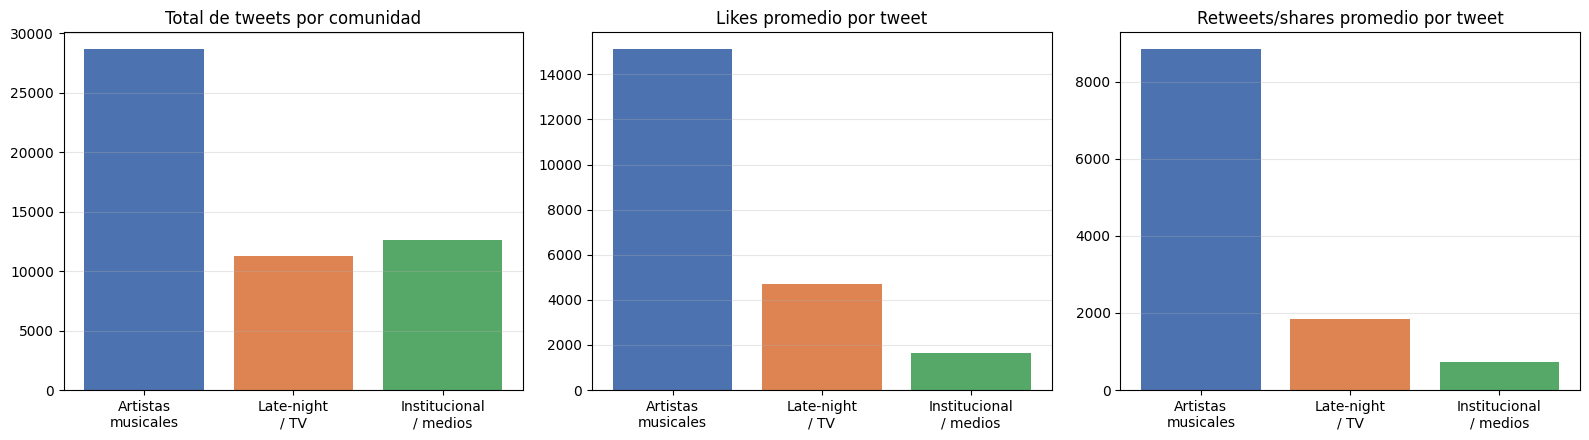

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
etiquetas = {0: 'Artistas\nmusicales', 1: 'Late-night\n/ TV', 2: 'Institucional\n/ medios'}
colores = ['#4C72B0', '#DD8452', '#55A868']
coms = sorted(resumen.index)
labels = [etiquetas[c] for c in coms]

axes[0].bar(labels, resumen.loc[coms, 'n_tweets'], color=colores)
axes[0].set_title('Total de tweets por comunidad')

axes[1].bar(labels, resumen.loc[coms, 'avg_likes'], color=colores)
axes[1].set_title('Likes promedio por tweet')

axes[2].bar(labels, resumen.loc[coms, 'avg_shares'], color=colores)
axes[2].set_title('Retweets/shares promedio por tweet')

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comunidades_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
hashtag_re = re.compile(r'#(\w+)')
df['hashtags'] = df['content'].apply(lambda x: [h.lower() for h in hashtag_re.findall(str(x))])

for com in sorted(df['community'].unique()):
    sub = df[df['community'] == com]
    c = Counter()
    for h in sub['hashtags']:
        c.update(h)
    print(f"Comunidad {com} ({etiquetas[com].replace(chr(10), ' ')}) — top hashtags:")
    print("  ", c.most_common(8), "\n")

Comunidad 0 (Artistas musicales) — top hashtags:
   [('ts1989', 165), ('confident', 149), ('purpose', 138), ('tbt', 136), ('1', 135), ('pieceofme', 135), ('taylurking', 125), ('whatdoyoumean', 100)] 

Comunidad 1 (Late-night / TV) — top hashtags:
   [('fallontonight', 1076), ('fallonmono', 152), ('thankyounotefriday', 134), ('jt2020tour', 119), ('cantstopthefeeling', 98), ('latenight', 94), ('the2020experience', 88), ('tbt', 87)] 

Comunidad 2 (Institucional / medios) — top hashtags:
   [('actonclimate', 277), ('dailyfluff', 215), ('lovetwitter', 163), ('doyourjob', 147), ('youtuberewind', 122), ('sotu', 117), ('getcovered', 105), ('theweekoninstagram', 103)] 



In [14]:
idioma_pct = (df.groupby('community')['language']
              .apply(lambda x: x.value_counts(normalize=True).head(3) * 100)
              .round(1))
print("Top 3 idiomas por comunidad (%):")
print(idioma_pct)
print()
print("Longitud promedio del texto del tweet (caracteres) por comunidad:")
print(df.groupby('community')['content_len'].mean().round(1))

Top 3 idiomas por comunidad (%):
community  0  
0          en     84.8
           und     8.7
           es      4.1
1          en     93.9
           und     2.6
           es      1.4
2          en     95.4
           und     3.7
           es      0.2
Name: language, dtype: float64

Longitud promedio del texto del tweet (caracteres) por comunidad:
community
0     81.2
1     98.2
2    104.1
Name: content_len, dtype: float64


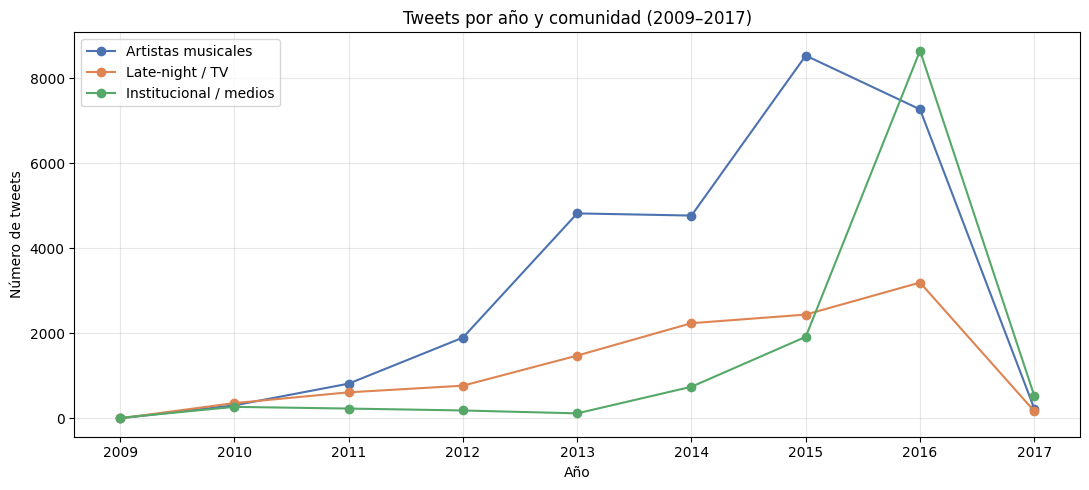

In [15]:
df['year'] = df['date_time_parsed'].dt.year
tweets_por_año = df.groupby(['year', 'community']).size().unstack(fill_value=0)
tweets_por_año.columns = [etiquetas[c].replace(chr(10), ' ') for c in tweets_por_año.columns]

fig, ax = plt.subplots(figsize=(11, 5))
tweets_por_año.plot(kind='line', marker='o', ax=ax, color=colores)
ax.set_title('Tweets por año y comunidad (2009–2017)')
ax.set_ylabel('Número de tweets')
ax.set_xlabel('Año')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('comunidades_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
print("Tweets con latitud/longitud no nulas:", df[['latitude','longitude']].dropna().shape[0], "de", len(df))
print("Tweets con país no nulo:", df['country'].notna().sum(), "de", len(df))
print()
print(df['country'].value_counts())
print()
print(df[df['latitude'].notna()][['author','content','country','latitude','longitude']])

Tweets con latitud/longitud no nulas: 1 de 52542
Tweets con país no nulo: 36 de 52542

country
Vereinigte Staaten    25
Portugal              11
Name: count, dtype: int64

        author                                            content  \
22581  Twitter  Coming soon! We're working with @foursquare so...   

                  country   latitude   longitude  
22581  Vereinigte Staaten  37.776973 -122.416523  
